# Deep Neural Network — sEMG Gesture Classification
## NinaPro DB7 | Exercise B | 17 Gestures (Classes 13–29) | EMG + ACC

**Paper:** Sri-iesaranusorn et al. (2021) — *Classification of 41 Hand and Wrist Movements via Surface Electromyogram Using Deep Neural Network*

### Paper-Exact Implementation:
- **Model**: Feed-forward DNN — 3 Fully Connected (FC) layers: 512 → 256 → 256 neurons
- **Input**: Hand-crafted features (RMS, MAV, MAVSLP, ZC, SSC, WL) per channel — NOT raw signal
- **Activation**: ReLU + Batch Normalization + 20% Dropout per layer
- **Weight Init**: He Uniform
- **Output**: Softmax
- **Optimizer**: Adam (lr=0.005, decay=0.00001) — no LR scheduler
- **Loss**: Cross-Entropy
- **Split**: 90:10 and 80:20 (stratified random, as instructed)
- **Scope**: DB7 Exercise B, gestures 13–29 (17 classes), EMG + ACC channels

## Cell 1 — Imports

In [1]:
import os, gc, time, json, warnings
from pathlib import Path
from copy import deepcopy
import numpy as np
import pandas as pd
from scipy import io
from scipy.signal import resample_poly
from math import gcd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('Imports done.')

Imports done.


## Cell 2 — Configuration

In [2]:
def _find_kaggle_input() -> Path:
    base = Path('/kaggle/input')
    if not base.exists():
        return Path('/kaggle/input/ninapro-db7/Dataset')
    def _has_subjects(p):
        return p.is_dir() and any(
            c.is_dir() and c.name.lower().startswith('subject_')
            for c in p.iterdir()
        )
    def _search(root, depth=0):
        if depth > 5: return None
        if _has_subjects(root): return root
        try:
            for child in sorted(root.iterdir()):
                if child.is_dir():
                    r = _search(child, depth + 1)
                    if r is not None: return r
        except PermissionError:
            pass
        return None
    r = _search(base)
    return r if r else Path('/kaggle/input/ninapro-db7/Dataset')


class Config:
    # ── Paths ──────────────────────────────────────────────────────────────
    KAGGLE_INPUT   = _find_kaggle_input()
    KAGGLE_WORKING = Path('/kaggle/working')
    CKPT_DIR       = KAGGLE_WORKING / 'ckpts_dnn_paper'
    DATA_CACHE_DIR = KAGGLE_WORKING / 'cache_dnn_paper'
    PLOT_DIR       = KAGGLE_WORKING / 'plots_dnn_paper'
    RESULTS_DIR    = KAGGLE_WORKING / 'results_dnn_paper'

    # ── Dataset ────────────────────────────────────────────────────────────
    SUBJECTS     = list(range(1, 23))   # DB7 has 22 subjects
    EMG_FS       = 2000
    ACC_FS       = 148
    TARGET_FS    = 2000
    EMG_KEY      = 'emg'
    ACC_KEY      = 'acc'
    LBL_KEY      = 'restimulus'
    GESTURE_MIN  = 13                   # Exercise B gesture range (inclusive)
    GESTURE_MAX  = 29
    N_CLASSES    = GESTURE_MAX - GESTURE_MIN + 1   # 17

    # ── Windowing (paper: 200 ms window, 100 ms stride) ────────────────────
    WIN_MS       = 200
    STEP_MS      = 100
    WIN_SAMPLES  = int(WIN_MS  * TARGET_FS / 1000)   # 400
    STEP_SAMPLES = int(STEP_MS * TARGET_FS / 1000)   # 200

    # ── Feature extraction (paper Section 2.2) ─────────────────────────────
    # ZC / SSC noise threshold for DB7 intact subjects = 1e-8
    ZC_SSC_THRESHOLD = 1e-8
    MAVSLP_SEGMENTS  = 3          # split window into N segments for MAVSLP

    # ── Splits ─────────────────────────────────────────────────────────────
    SPLIT_RATIOS      = [(0.90, 0.10), (0.80, 0.20)]
    VAL_FRAC_OF_TRAIN = 0.10      # 10 % of train → validation

    # ── Training (paper Section 2.3) ───────────────────────────────────────
    MIN_EPOCHS   = 100
    MAX_EPOCHS   = 250
    PATIENCE     = 20
    BATCH_SIZE   = 256
    LR           = 0.005          # paper: 0.005
    DECAY        = 1e-5           # paper: 0.00001
    # NO LR scheduler — paper uses none
    DROPOUT      = 0.20           # paper: 20 %
    NUM_WORKERS  = 2

    # ── DNN hidden layer sizes (paper Figure 5) ────────────────────────────
    HIDDEN = [512, 256, 256]      # three FC layers

    # ── Reproducibility ────────────────────────────────────────────────────
    SEED   = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


import random
random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

for d in [Config.CKPT_DIR, Config.DATA_CACHE_DIR,
          Config.PLOT_DIR, Config.RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Device      : {Config.DEVICE}')
print(f'Window      : {Config.WIN_SAMPLES} samples ({Config.WIN_MS} ms)')
print(f'Step        : {Config.STEP_SAMPLES} samples ({Config.STEP_MS} ms)')
print(f'Gestures    : {Config.GESTURE_MIN}–{Config.GESTURE_MAX} ({Config.N_CLASSES} classes)')
print(f'LR / decay  : {Config.LR} / {Config.DECAY}')
print(f'Dropout     : {Config.DROPOUT}')
print(f'DNN layers  : {Config.HIDDEN}')

Device      : cuda
Window      : 400 samples (200 ms)
Step        : 200 samples (100 ms)
Gestures    : 13–29 (17 classes)
LR / decay  : 0.005 / 1e-05
Dropout     : 0.2
DNN layers  : [512, 256, 256]


## Cell 3 — Data Loading & Preprocessing

In [3]:
class EMGAccPreprocessor:
    """
    Loads EMG + ACC from a .mat file.
    ACC is upsampled to EMG rate when lengths differ.
    Only gesture labels in [GESTURE_MIN, GESTURE_MAX] are kept.
    """
    def _find_key(self, data, candidates):
        for c in candidates:
            for k in data:
                if k.lower() == c.lower():
                    return k
        return None

    def apply(self, mat_path: Path):
        data    = io.loadmat(str(mat_path))
        emg_key = self._find_key(data, [Config.EMG_KEY])
        acc_key = self._find_key(data, [Config.ACC_KEY, 'glove'])
        lbl_key = self._find_key(
            data, [Config.LBL_KEY, 'stimulus', 'label', 'labels'])

        if emg_key is None:
            raise KeyError(f'No EMG key in {mat_path.name}.')
        if lbl_key is None:
            raise KeyError(f'No label key in {mat_path.name}.')

        emg    = data[emg_key].astype(np.float32)
        labels = data[lbl_key].flatten().astype(np.int32)

        if acc_key is not None:
            acc = data[acc_key].astype(np.float32)
            if len(acc) != len(emg):
                factor = len(emg) / len(acc)
                up     = round(factor * Config.ACC_FS)
                down   = Config.ACC_FS
                g      = gcd(up, down)
                acc    = resample_poly(acc, up // g, down // g,
                                       axis=0).astype(np.float32)
            if len(acc) > len(emg):
                acc = acc[:len(emg)]
            elif len(acc) < len(emg):
                pad = np.zeros((len(emg) - len(acc), acc.shape[1]),
                               dtype=np.float32)
                acc = np.vstack([acc, pad])
        else:
            acc = np.zeros((len(emg), 0), dtype=np.float32)

        n      = min(len(emg), len(labels))
        emg, acc, labels = emg[:n], acc[:n], labels[:n]

        mask   = (labels >= Config.GESTURE_MIN) & (labels <= Config.GESTURE_MAX)
        return emg[mask], acc[mask], labels[mask]


## Cell 4 — Subject Loader & Window Builder

In [4]:
class SubjectLoader:
    def __init__(self):
        self.preprocessor = EMGAccPreprocessor()
        self.cache_dir    = Config.DATA_CACHE_DIR

    def _ckpt_path(self, sid): return self.cache_dir / f'subj_{sid:02d}_exB.npz'

    def _find_subject_dir(self, sid):
        candidates = [
            Config.KAGGLE_INPUT / f'Subject_{sid}',
            Config.KAGGLE_INPUT / f'subject_{sid}',
            Config.KAGGLE_INPUT / f'S{sid}',
            Config.KAGGLE_INPUT / f's{sid}',
        ]
        for p in candidates:
            if p.is_dir(): return p
        for p in sorted(Config.KAGGLE_INPUT.iterdir()):
            if p.is_dir() and p.name.lower().endswith(str(sid)):
                return p
        raise FileNotFoundError(
            f'Cannot find subject {sid} under {Config.KAGGLE_INPUT}.')

    def _load_subject(self, sid):
        subj_dir  = self._find_subject_dir(sid)
        mat_files = sorted(subj_dir.glob('*.mat')) or sorted(subj_dir.rglob('*.mat'))
        emg_parts, acc_parts, lbl_parts = [], [], []
        for mat_file in mat_files:
            try:
                emg, acc, lbl = self.preprocessor.apply(mat_file)
                if len(emg) > 0:
                    emg_parts.append(emg)
                    acc_parts.append(acc)
                    lbl_parts.append(lbl)
            except Exception as e:
                print(f'  Skip {mat_file.name}: {e}')
        if not emg_parts:
            raise RuntimeError(f'No valid data for subject {sid}')
        emg_all = np.vstack(emg_parts)
        acc_all = (np.vstack(acc_parts)
                   if all(a.shape[1] > 0 for a in acc_parts)
                   else np.zeros((sum(len(e) for e in emg_parts), 0),
                                  dtype=np.float32))
        lbl_all = np.concatenate(lbl_parts)
        return emg_all, acc_all, lbl_all

    def process_all(self, subjects=None):
        subjects  = subjects or Config.SUBJECTS
        available = []
        n_acc_ch  = None
        for sid in tqdm(subjects, desc='Loading subjects'):
            ckpt = self._ckpt_path(sid)
            if ckpt.exists():
                data     = np.load(ckpt, allow_pickle=True)
                n_acc_ch = int(data['n_acc_ch'])
                available.append(sid)
                print(f'  Subject {sid:02d}: checkpoint ({data["n_rows"]} rows, '
                      f'{n_acc_ch} ACC ch)')
                continue
            try:
                emg, acc, lbl = self._load_subject(sid)
                n_acc_ch = acc.shape[1]
                np.savez_compressed(
                    ckpt, emg=emg, acc=acc, labels=lbl,
                    n_acc_ch=np.array(n_acc_ch),
                    n_rows=np.array(len(emg)))
                available.append(sid)
                print(f'  Subject {sid:02d}: saved {len(emg):,} rows | '
                      f'EMG {emg.shape[1]} ch | ACC {n_acc_ch} ch')
                del emg, acc, lbl; gc.collect()
            except Exception as exc:
                print(f'  Subject {sid:02d}: FAILED — {exc}')
        return available, (n_acc_ch or 0)

    def build_windows(self, subjects, n_acc_ch):
        """
        Returns raw windowed segments (N, n_ch, WIN_SAMPLES).
        Feature extraction is done separately before model input.
        """
        W, S   = Config.WIN_SAMPLES, Config.STEP_SAMPLES
        X_list, y_list = [], []
        for sid in tqdm(subjects, desc='Windowing'):
            ckpt = self._ckpt_path(sid)
            if not ckpt.exists(): continue
            d      = np.load(ckpt)
            emg    = d['emg'].astype(np.float32)
            acc    = d['acc'].astype(np.float32)
            labels = d['labels'].astype(np.int32)
            sig    = np.concatenate([emg, acc], axis=1) if acc.shape[1] > 0 else emg
            T      = len(sig)
            for start in range(0, T - W + 1, S):
                end  = start + W
                seg  = sig[start:end]          # (WIN_SAMPLES, n_ch)
                lbls = labels[start:end]
                lbl  = int(np.bincount(
                    lbls - Config.GESTURE_MIN,
                    minlength=Config.N_CLASSES).argmax())
                X_list.append(seg.T)           # (n_ch, WIN_SAMPLES)
                y_list.append(lbl)
            del emg, acc, labels, sig, d; gc.collect()
        X = np.stack(X_list, axis=0).astype(np.float32)
        y = np.array(y_list, dtype=np.int64)
        n_ch = X.shape[1]
        print(f'\nWindowed: X={X.shape}  y={y.shape}  classes={np.unique(y).tolist()}')
        return X, y, n_ch


## Cell 5 — Hand-Crafted Feature Extraction

Implements **exactly** the 6 features from the paper (Section 2.2):
- **RMS** — Root Mean Square: average signal power per channel
- **MAV** — Mean Absolute Value: average signal magnitude per channel
- **MAVSLP** — MAV Slope: how MAV changes across sub-segments of the window
- **ZC** — Zero Crossings: how often signal crosses zero (with noise threshold T)
- **SSC** — Slope Sign Changes: how often signal direction reverses (with threshold T)
- **WL** — Waveform Length: total cumulative length of the signal wave

All 6 features are computed **per channel**, then concatenated → feature vector.

In [5]:
def extract_features_window(window: np.ndarray,
                             T: float = Config.ZC_SSC_THRESHOLD,
                             n_segments: int = Config.MAVSLP_SEGMENTS) -> np.ndarray:
    """
    Extract 6 hand-crafted features per channel from one window.

    Args:
        window    : np.ndarray of shape (n_ch, WIN_SAMPLES)  — one window
        T         : noise threshold for ZC and SSC
        n_segments: number of sub-segments for MAVSLP

    Returns:
        feature vector of shape (n_ch * 6,)  [if MAVSLP gives n_seg-1 slopes
        then total = n_ch * (5 + (n_segments-1))]
    """
    n_ch, L = window.shape
    feats   = []

    for ch in range(n_ch):
        x = window[ch]   # (L,)

        # 1. RMS — Root Mean Square
        rms = np.sqrt(np.mean(x ** 2))

        # 2. MAV — Mean Absolute Value
        mav = np.mean(np.abs(x))

        # 3. MAVSLP — Mean Absolute Value Slope
        #    Split window into n_segments, compute MAV of each, then differences
        seg_len  = L // n_segments
        mav_segs = [np.mean(np.abs(x[i*seg_len:(i+1)*seg_len]))
                    for i in range(n_segments)]
        mavslp   = np.diff(mav_segs)          # (n_segments-1,) values

        # 4. ZC — Zero Crossings  (Hudgins et al. 1993, paper Eq. 1-2)
        #    Count sign changes where the jump size >= T
        zc = 0
        for k in range(L - 1):
            if ((x[k] < 0 and x[k+1] > 0) or (x[k] > 0 and x[k+1] < 0)):
                if abs(x[k] - x[k+1]) >= T:
                    zc += 1

        # 5. SSC — Slope Sign Changes  (Hudgins et al. 1993, paper Eq. 3-4)
        #    Count local peaks/troughs where slope change size >= T
        ssc = 0
        for k in range(1, L - 1):
            if ((x[k] > x[k-1] and x[k] > x[k+1]) or
                    (x[k] < x[k-1] and x[k] < x[k+1])):
                if (abs(x[k] - x[k+1]) >= T or abs(x[k] - x[k-1]) >= T):
                    ssc += 1

        # 6. WL — Waveform Length
        wl = np.sum(np.abs(np.diff(x)))

        feats.extend([rms, mav] + list(mavslp) + [zc, ssc, wl])

    return np.array(feats, dtype=np.float32)


def extract_features_batch(X_raw: np.ndarray,
                            T: float = Config.ZC_SSC_THRESHOLD,
                            n_segments: int = Config.MAVSLP_SEGMENTS) -> np.ndarray:
    """
    Extract features for all windows.
    X_raw : (N, n_ch, WIN_SAMPLES)
    Returns: (N, n_features)
    """
    N    = X_raw.shape[0]
    feats = [
        extract_features_window(X_raw[i], T=T, n_segments=n_segments)
        for i in tqdm(range(N), desc='Feature extraction')
    ]
    return np.vstack(feats).astype(np.float32)


print('Feature extraction functions defined.')
print(f'ZC/SSC threshold T = {Config.ZC_SSC_THRESHOLD}')
print(f'MAVSLP segments    = {Config.MAVSLP_SEGMENTS} -> {Config.MAVSLP_SEGMENTS-1} slope values per channel')

Feature extraction functions defined.
ZC/SSC threshold T = 1e-08
MAVSLP segments    = 3 -> 2 slope values per channel


## Cell 6 — Dataset Class

In [6]:
class FeatureDataset(Dataset):
    """PyTorch dataset for feature vectors (not raw signal)."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):           return len(self.y)
    def __getitem__(self, idx):  return self.X[idx], self.y[idx]

print('FeatureDataset defined.')

FeatureDataset defined.


## Cell 7 — DNN Model (Paper-Exact)

**Feed-Forward Deep Neural Network** as described in the paper (Section 2.3 & Figure 5):
- 3 hidden FC (Fully Connected) layers: **512 → 256 → 256**
- Each layer: **FC → Batch Normalization → ReLU → Dropout (20%)**
- Weight initialization: **He Uniform** (paper uses He uniform for ReLU layers)
- Output layer: **FC → Softmax**

In [7]:
class PaperDNN(nn.Module):
    """
    Feed-forward DNN — exact replica of the paper model (Section 2.3, Figure 5).

    Architecture:
        Input  → FC(512) → BN → ReLU → Dropout(0.20)
               → FC(256) → BN → ReLU → Dropout(0.20)
               → FC(256) → BN → ReLU → Dropout(0.20)
               → FC(n_classes) → Softmax

    Weight init : He Uniform (as stated in paper)
    """
    def __init__(self, n_features: int, n_classes: int,
                 hidden: list = None, dropout: float = None):
        super().__init__()
        hidden  = hidden  or Config.HIDDEN
        dropout = dropout or Config.DROPOUT

        self.n_features = n_features
        self.n_classes  = n_classes

        layers = []
        in_dim = n_features
        for h in hidden:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
            ]
            in_dim = h

        layers += [nn.Linear(in_dim, n_classes)]
        # Softmax is applied in forward (not inside Sequential
        # so CrossEntropyLoss can work with logits during training,
        # but we apply softmax explicitly for inference / probability output)

        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        """He Uniform initialization — as specified in the paper."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in',
                                         nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, return_proba=False):
        logits = self.net(x)
        if return_proba:
            return F.softmax(logits, dim=1)
        return logits

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Quick sanity check
_dummy_feat = 12 * (2 + (Config.MAVSLP_SEGMENTS - 1) + 3)  # rough estimate
_m = PaperDNN(n_features=_dummy_feat, n_classes=Config.N_CLASSES)
print(f'PaperDNN architecture:\n{_m}')
print(f'\nParam count (rough, dummy input): {_m.count_params():,}')
del _m

PaperDNN architecture:
PaperDNN(
  (net): Sequential(
    (0): Linear(in_features=84, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=256, out_features=17, bias=True)
  )
)

Param count (rough, dummy input): 247,057


## Cell 8 — Trainer

In [8]:
class Trainer:
    """
    Trains PaperDNN with:
      - Adam optimizer  lr=0.005, decay=0.00001  (paper values)
      - CrossEntropyLoss
      - NO LR scheduler (paper uses none)
      - Early stopping after PATIENCE epochs without val_loss improvement
        (only active after MIN_EPOCHS)
      - Saves best checkpoint by val_loss
    """
    def __init__(self, model, save_path: Path):
        self.model     = model.to(Config.DEVICE)
        self.save_path = save_path
        self.history   = {'train_loss': [], 'val_loss': [],
                          'train_acc':  [], 'val_acc':  []}

    def _run_epoch(self, loader, optimizer=None, criterion=None):
        training = optimizer is not None
        self.model.train(training)
        total_loss, correct, total = 0.0, 0, 0
        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for X, y in loader:
                X, y   = X.to(Config.DEVICE), y.to(Config.DEVICE)
                logits = self.model(X)
                loss   = criterion(logits, y)
                if training:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                total_loss += loss.item() * len(y)
                correct    += (logits.argmax(1) == y).sum().item()
                total      += len(y)
        return total_loss / total, correct / total

    def fit(self, train_loader, val_loader):
        # Paper: Adam with lr=0.005, decay=0.00001, NO scheduler
        optimizer     = Adam(self.model.parameters(),
                             lr=Config.LR,
                             weight_decay=Config.DECAY)
        criterion     = nn.CrossEntropyLoss()
        best_val_loss = float('inf')
        patience_cnt  = 0
        start_wall    = time.perf_counter()

        for epoch in range(1, Config.MAX_EPOCHS + 1):
            tr_loss, tr_acc = self._run_epoch(train_loader, optimizer, criterion)
            vl_loss, vl_acc = self._run_epoch(val_loader,   criterion=criterion)

            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(vl_loss)
            self.history['train_acc'].append(tr_acc)
            self.history['val_acc'].append(vl_acc)

            if vl_loss < best_val_loss:
                best_val_loss = vl_loss
                patience_cnt  = 0
                torch.save(self.model.state_dict(), self.save_path)
            else:
                patience_cnt += 1

            if epoch % 10 == 0:
                print(f'  Epoch {epoch:3d}  '
                      f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  '
                      f'val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}')

            if epoch >= Config.MIN_EPOCHS and patience_cnt >= Config.PATIENCE:
                print(f'  Early stop at epoch {epoch}')
                break

        self.train_wall = time.perf_counter() - start_wall
        print(f'  Training wall-clock : {self.train_wall:.1f} s'
              f'  |  Best val_loss: {best_val_loss:.4f}')
        return self

print('Trainer defined.')

Trainer defined.


## Cell 9 — Evaluator + Visualisations

In [9]:
class Evaluator:
    """
    Loads the best saved model and computes the full metric suite
    on the test set. Produces confusion matrix and ROC curves.
    """
    def __init__(self, model_kwargs, save_path: Path,
                 n_classes: int, class_names: list):
        self.model_kwargs = model_kwargs
        self.save_path    = save_path
        self.n_classes    = n_classes
        self.class_names  = class_names

    def _load_model(self):
        model = PaperDNN(**self.model_kwargs)
        model.load_state_dict(torch.load(self.save_path,
                                          map_location=Config.DEVICE))
        return model.to(Config.DEVICE).eval()

    def evaluate(self, test_loader, split_tag: str):
        model = self._load_model()
        all_preds, all_proba, all_true = [], [], []
        start_wall = time.perf_counter()
        with torch.no_grad():
            for X, y in test_loader:
                X      = X.to(Config.DEVICE)
                proba  = model(X, return_proba=True).cpu().numpy()
                preds  = proba.argmax(axis=1)
                all_proba.append(proba)
                all_preds.append(preds)
                all_true.append(y.numpy())
        test_wall = time.perf_counter() - start_wall

        all_proba = np.vstack(all_proba)
        all_preds = np.concatenate(all_preds)
        all_true  = np.concatenate(all_true)

        acc       = accuracy_score(all_true, all_preds)
        prec_w    = precision_score(all_true, all_preds,
                                    average='weighted', zero_division=0)
        rec_w     = recall_score(all_true, all_preds,
                                  average='weighted', zero_division=0)
        f1_w      = f1_score(all_true, all_preds,
                             average='weighted', zero_division=0)
        # Macro metrics (paper uses macro recall as 'balanced accuracy')
        prec_mac  = precision_score(all_true, all_preds,
                                    average='macro', zero_division=0)
        rec_mac   = recall_score(all_true, all_preds,
                                  average='macro', zero_division=0)   # = balanced acc
        f1_mac    = f1_score(all_true, all_preds,
                             average='macro', zero_division=0)
        try:
            roc_auc = roc_auc_score(all_true, all_proba,
                                    multi_class='ovr', average='weighted',
                                    labels=list(range(self.n_classes)))
        except Exception:
            roc_auc = float('nan')

        per_class_acc = {}
        for c in range(self.n_classes):
            mask = all_true == c
            if mask.sum() > 0:
                per_class_acc[self.class_names[c]] = float(
                    accuracy_score(all_true[mask], all_preds[mask]))

        metrics = dict(
            split=split_tag,
            accuracy=acc,
            balanced_accuracy=rec_mac,    # macro recall = balanced acc (paper)
            precision_w=prec_w,
            recall_w=rec_w,
            f1_w=f1_w,
            precision_mac=prec_mac,
            recall_mac=rec_mac,
            f1_mac=f1_mac,
            roc_auc_w=roc_auc,
            per_class_acc=per_class_acc,
            test_wall_s=test_wall,
            test_samples=len(all_true),
        )

        tag = split_tag.replace(':', '_')
        self._plot_confusion(all_true, all_preds, split_tag, tag)
        self._plot_roc(all_true, all_proba, split_tag, tag)
        return metrics, all_true, all_proba

    def _plot_confusion(self, y_true, y_pred, title, tag):
        cm  = confusion_matrix(y_true, y_pred,
                                labels=list(range(self.n_classes)))
        cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        for ax, mat, label, fmt in zip(
                axes, [cm, cmn], ['Count', 'Normalised'],
                ['d', '.2f']):
            sns.heatmap(mat, ax=ax, cmap='Blues',
                        xticklabels=self.class_names,
                        yticklabels=self.class_names,
                        annot=True, fmt=fmt, linewidths=0.3)
            ax.set_title(f'Confusion Matrix ({label}) — PaperDNN {title}',
                         fontsize=12)
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.tick_params(axis='y', rotation=0,  labelsize=8)
        plt.tight_layout()
        path = Config.PLOT_DIR / f'cm_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show(); plt.close('all')
        print(f'  CM saved → {path.name}')

    def _plot_roc(self, y_true, y_proba, title, tag):
        fig, ax = plt.subplots(figsize=(10, 7))
        colors  = plt.cm.tab20(np.linspace(0, 1, self.n_classes))
        for c in range(self.n_classes):
            if (y_true == c).sum() == 0: continue
            fpr, tpr, _ = roc_curve((y_true == c).astype(int), y_proba[:, c])
            try:
                auc_c = roc_auc_score((y_true == c).astype(int), y_proba[:, c])
            except Exception:
                auc_c = float('nan')
            ax.plot(fpr, tpr, color=colors[c], lw=1.3,
                    label=f'{self.class_names[c]} (AUC={auc_c:.2f})')
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC Curves (OvR) — PaperDNN {title}', fontsize=12)
        ax.legend(fontsize=7, ncol=2, loc='lower right')
        plt.tight_layout()
        path = Config.PLOT_DIR / f'roc_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show(); plt.close('all')
        print(f'  ROC saved → {path.name}')

print('Evaluator defined.')

Evaluator defined.


## Cell 10 — Learning Curve Plot

In [10]:
def plot_learning_curves(history: dict, split_tag: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train loss',  lw=1.5)
    axes[0].plot(epochs, history['val_loss'],   label='Val loss',    lw=1.5, linestyle='--')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].set_title(f'PaperDNN — Loss Curve ({split_tag})')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train acc',  lw=1.5)
    axes[1].plot(epochs, history['val_acc'],   label='Val acc',    lw=1.5, linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'PaperDNN — Accuracy Curve ({split_tag})')
    axes[1].legend()

    plt.tight_layout()
    tag  = split_tag.replace(':', '_')
    path = Config.PLOT_DIR / f'curves_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f'  Curves saved → {path.name}')

print('Learning curve function defined.')

Learning curve function defined.


## Cell 11 — Per-Class Accuracy Bar Chart

In [11]:
def plot_per_class_accuracy(per_class_acc: dict, split_tag: str):
    names  = list(per_class_acc.keys())
    values = list(per_class_acc.values())
    colors = ['#2ecc71' if v >= 0.80 else '#e74c3c' for v in values]

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(names, values, color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(0.80, color='black', linestyle='--', lw=1.2, label='80% threshold')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Gesture Class')
    ax.set_ylabel('Per-Class Accuracy')
    ax.set_title(f'PaperDNN — Per-Class Accuracy ({split_tag})  '
                 f'[green ≥ 80%, red < 80%]')
    ax.legend()
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    tag  = split_tag.replace(':', '_')
    path = Config.PLOT_DIR / f'per_class_acc_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f'  Per-class chart saved → {path.name}')

print('Per-class accuracy plot function defined.')

Per-class accuracy plot function defined.


## Cell 12 — Split Experiment

In [12]:
class SplitExperiment:
    """
    Runs the full pipeline for one train/test ratio:
      1. Stratified random split (as instructed by teacher)
      2. Feature extraction (paper-exact: RMS, MAV, MAVSLP, ZC, SSC, WL)
      3. Z-score normalization per feature (paper Section 2.2)
      4. Train PaperDNN
      5. Evaluate and produce all visuals
    """
    def __init__(self, X_raw: np.ndarray, y: np.ndarray,
                 n_channels: int, n_classes: int, class_names: list):
        self.X_raw      = X_raw
        self.y          = y
        self.n_channels = n_channels
        self.n_classes  = n_classes
        self.class_names= class_names

    def run(self, train_frac: float, test_frac: float) -> dict:
        tag = f'{int(train_frac*100)}:{int(test_frac*100)}'
        print(f'\n{"="*70}')
        print(f'  Split {tag}  |  train={train_frac:.0%}  test={test_frac:.0%}')
        print(f'{"="*70}')

        # ── 1. Stratified split ───────────────────────────────────────────
        X_tv, X_test, y_tv, y_test = train_test_split(
            self.X_raw, self.y,
            test_size=test_frac,
            random_state=Config.SEED,
            stratify=self.y,
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X_tv, y_tv,
            test_size=Config.VAL_FRAC_OF_TRAIN,
            random_state=Config.SEED,
            stratify=y_tv if len(np.unique(y_tv)) == self.n_classes else None,
        )
        print(f'  Sizes  train={len(y_train):,}  val={len(y_val):,}  '
              f'test={len(y_test):,}')

        # ── 2. Feature extraction (paper-exact) ───────────────────────────
        print('  Extracting features...')
        Xf_train = extract_features_batch(X_train)
        Xf_val   = extract_features_batch(X_val)
        Xf_test  = extract_features_batch(X_test)
        n_feats  = Xf_train.shape[1]
        print(f'  Feature vector size : {n_feats}')

        # ── 3. Z-score normalization (paper Section 2.2) ──────────────────
        scaler   = StandardScaler()
        Xf_train = scaler.fit_transform(Xf_train).astype(np.float32)
        Xf_val   = scaler.transform(Xf_val).astype(np.float32)
        Xf_test  = scaler.transform(Xf_test).astype(np.float32)

        # ── 4. DataLoaders ────────────────────────────────────────────────
        tr_loader = DataLoader(
            FeatureDataset(Xf_train, y_train),
            batch_size=Config.BATCH_SIZE, shuffle=True,
            num_workers=Config.NUM_WORKERS, pin_memory=True)
        val_loader = DataLoader(
            FeatureDataset(Xf_val, y_val),
            batch_size=Config.BATCH_SIZE, shuffle=False,
            num_workers=Config.NUM_WORKERS, pin_memory=True)
        tst_loader = DataLoader(
            FeatureDataset(Xf_test, y_test),
            batch_size=Config.BATCH_SIZE, shuffle=False,
            num_workers=Config.NUM_WORKERS, pin_memory=True)

        # ── 5. Build model ────────────────────────────────────────────────
        model_kwargs = dict(n_features=n_feats, n_classes=self.n_classes)
        model        = PaperDNN(**model_kwargs)
        save_path    = Config.CKPT_DIR / f'paperdnn_{tag.replace(":","_")}.pt'
        print(f'  PaperDNN params     : {model.count_params():,}')
        print(f'  Feature vector size : {n_feats}')

        # ── 6. Train ──────────────────────────────────────────────────────
        trainer = Trainer(model, save_path)
        trainer.fit(tr_loader, val_loader)
        plot_learning_curves(trainer.history, tag)

        # ── 7. Evaluate ───────────────────────────────────────────────────
        evaluator = Evaluator(model_kwargs, save_path,
                              self.n_classes, self.class_names)
        metrics, y_true, y_proba = evaluator.evaluate(tst_loader, tag)
        plot_per_class_accuracy(metrics['per_class_acc'], tag)

        # attach extra info
        metrics['train_wall_s']  = trainer.train_wall
        metrics['n_params']      = model.count_params()
        metrics['n_features']    = n_feats
        metrics['epochs_trained']= len(trainer.history['train_loss'])
        metrics['train_size']    = int(len(y_train))
        metrics['val_size']      = int(len(y_val))
        metrics['test_size']     = int(len(y_test))

        print(f'\n  ── Results {tag} ────────────────────────────────')
        print(f'  Overall Accuracy    : {metrics["accuracy"]:.4f}')
        print(f'  Balanced Accuracy   : {metrics["balanced_accuracy"]:.4f}  '
              f'(macro recall — paper metric)')
        print(f'  Precision (weighted): {metrics["precision_w"]:.4f}')
        print(f'  Recall    (weighted): {metrics["recall_w"]:.4f}')
        print(f'  F1        (weighted): {metrics["f1_w"]:.4f}')
        print(f'  Macro Precision     : {metrics["precision_mac"]:.4f}')
        print(f'  Macro Recall        : {metrics["recall_mac"]:.4f}')
        print(f'  Macro F1            : {metrics["f1_mac"]:.4f}')
        print(f'  ROC-AUC (weighted)  : {metrics["roc_auc_w"]:.4f}')
        print(f'  Train wall          : {metrics["train_wall_s"]:.1f} s')
        print(f'  Test wall           : {metrics["test_wall_s"]:.2f} s')
        print(f'  Model saved → {save_path.name}')
        return metrics, y_true, y_proba

print('SplitExperiment defined.')

SplitExperiment defined.


## Cell 13 — Failure Mode Analysis & Summary Chart

In [13]:
def analyse_failure_modes(all_metrics: list, class_names: list):
    print(f'\n{"="*70}')
    print('  FAILURE MODE ANALYSIS — PaperDNN')
    print(f'{"="*70}')

    class_accs = {c: [] for c in class_names}
    for m in all_metrics:
        for c, acc in m.get('per_class_acc', {}).items():
            if c in class_accs:
                class_accs[c].append(acc)

    mean_class_acc = {c: np.mean(v) for c, v in class_accs.items() if v}
    sorted_acc     = sorted(mean_class_acc.items(), key=lambda x: x[1])

    print('\n  Per-class mean accuracy (worst → best):')
    for name, acc in sorted_acc:
        bar = '█' * int(acc * 30)
        tag = '  ✗ difficult' if acc < 0.80 else ''
        print(f'    {name:>8s}  {acc:.3f}  {bar}{tag}')

    best_idx = int(np.argmax([m['f1_w'] for m in all_metrics]))
    best     = all_metrics[best_idx]
    print(f'\n  BEST split (by weighted F1): {best["split"]}')
    print(f'  Overall Accuracy  : {best["accuracy"]:.4f}')
    print(f'  Balanced Accuracy : {best["balanced_accuracy"]:.4f}')
    print(f'  F1 (weighted)     : {best["f1_w"]:.4f}')
    print(f'  ROC-AUC           : {best["roc_auc_w"]:.4f}')

    # ── Summary comparison bar chart ──────────────────────────────────────
    splits = [m['split'] for m in all_metrics]
    accs   = [m['accuracy']          for m in all_metrics]
    b_accs = [m['balanced_accuracy'] for m in all_metrics]
    f1s    = [m['f1_w']              for m in all_metrics]

    x = np.arange(len(splits))
    w = 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w, accs,   w, label='Overall Accuracy', color='steelblue')
    ax.bar(x,     b_accs, w, label='Balanced Accuracy (macro recall)',
           color='mediumseagreen')
    ax.bar(x + w, f1s,    w, label='F1 (weighted)',    color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.10)
    ax.set_title('PaperDNN — Overall / Balanced Accuracy & Weighted F1 across Splits')
    ax.legend()
    for xi, (a, b, f) in enumerate(zip(accs, b_accs, f1s)):
        ax.text(xi - w, a + 0.01, f'{a:.3f}', ha='center', va='bottom', fontsize=8)
        ax.text(xi,     b + 0.01, f'{b:.3f}', ha='center', va='bottom', fontsize=8)
        ax.text(xi + w, f + 0.01, f'{f:.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    path = Config.PLOT_DIR / 'summary_all_splits.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f'\n  Summary chart saved → {path.name}')
    return best

print('Failure mode analysis function defined.')

Failure mode analysis function defined.


## Cell 14 — MAIN PIPELINE


  STEP 1 — Loading NinaPro DB7 (Exercise B, gestures 13–29)


Loading subjects:   0%|          | 0/22 [00:00<?, ?it/s]

  Subject 01: saved 836,278 rows | EMG 12 ch | ACC 36 ch
  Subject 02: saved 981,857 rows | EMG 12 ch | ACC 36 ch
  Subject 03: saved 793,505 rows | EMG 12 ch | ACC 36 ch
  Subject 04: saved 1,030,056 rows | EMG 12 ch | ACC 36 ch
  Subject 05: saved 727,456 rows | EMG 12 ch | ACC 36 ch
  Subject 06: saved 791,365 rows | EMG 12 ch | ACC 36 ch
  Subject 07: saved 633,593 rows | EMG 12 ch | ACC 36 ch
  Subject 08: saved 740,815 rows | EMG 12 ch | ACC 36 ch
  Subject 09: saved 802,119 rows | EMG 12 ch | ACC 36 ch
  Subject 10: saved 723,376 rows | EMG 12 ch | ACC 36 ch
  Subject 11: saved 1,043,164 rows | EMG 12 ch | ACC 36 ch
  Subject 12: saved 750,726 rows | EMG 12 ch | ACC 36 ch
  Subject 13: saved 830,746 rows | EMG 12 ch | ACC 36 ch
  Subject 14: saved 803,185 rows | EMG 12 ch | ACC 36 ch
  Subject 15: saved 818,191 rows | EMG 12 ch | ACC 36 ch
  Subject 16: saved 801,268 rows | EMG 12 ch | ACC 36 ch
  Subject 17: saved 734,520 rows | EMG 12 ch | ACC 36 ch
  Subject 18: saved 792,861

Windowing:   0%|          | 0/22 [00:00<?, ?it/s]


Windowed: X=(87614, 48, 400)  y=(87614,)  classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

  Total windows  : 87,614
  Input channels : 48 (EMG=12, ACC=36)
  Window size    : 400 samples (200 ms)
  Classes        : 17 → ['G13', 'G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21', 'G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29']
       G13:   4,701 windows (5.4%)
       G14:   4,298 windows (4.9%)
       G15:   4,150 windows (4.7%)
       G16:   5,088 windows (5.8%)
       G17:   4,374 windows (5.0%)
       G18:   4,898 windows (5.6%)
       G19:   5,070 windows (5.8%)
       G20:   4,873 windows (5.6%)
       G21:   5,090 windows (5.8%)
       G22:   5,348 windows (6.1%)
       G23:   5,248 windows (6.0%)
       G24:   6,457 windows (7.4%)
       G25:   5,463 windows (6.2%)
       G26:   6,465 windows (7.4%)
       G27:   5,225 windows (6.0%)
       G28:   5,399 windows (6.2%)
       G29:   5,467 windows (6.2%)

  STEP 3 — Training & Evaluation (PaperDNN, 

Feature extraction:   0%|          | 0/70966 [00:00<?, ?it/s]

Feature extraction:   0%|          | 0/7886 [00:00<?, ?it/s]

Feature extraction:   0%|          | 0/8762 [00:00<?, ?it/s]

  Feature vector size : 336
  PaperDNN params     : 376,081
  Feature vector size : 336
  Epoch  10  train_loss=0.3580  train_acc=0.8687  val_loss=0.2979  val_acc=0.8915
  Epoch  20  train_loss=0.2599  train_acc=0.9064  val_loss=0.2561  val_acc=0.9076
  Epoch  30  train_loss=0.2254  train_acc=0.9194  val_loss=0.2252  val_acc=0.9181
  Epoch  40  train_loss=0.2083  train_acc=0.9266  val_loss=0.2238  val_acc=0.9224
  Epoch  50  train_loss=0.1952  train_acc=0.9310  val_loss=0.2221  val_acc=0.9219
  Epoch  60  train_loss=0.1867  train_acc=0.9340  val_loss=0.2196  val_acc=0.9262
  Epoch  70  train_loss=0.1831  train_acc=0.9362  val_loss=0.2205  val_acc=0.9242
  Epoch  80  train_loss=0.1731  train_acc=0.9404  val_loss=0.2229  val_acc=0.9228
  Epoch  90  train_loss=0.1739  train_acc=0.9382  val_loss=0.2210  val_acc=0.9270
  Epoch 100  train_loss=0.1693  train_acc=0.9404  val_loss=0.2175  val_acc=0.9275
  Early stop at epoch 100
  Training wall-clock : 185.9 s  |  Best val_loss: 0.2052


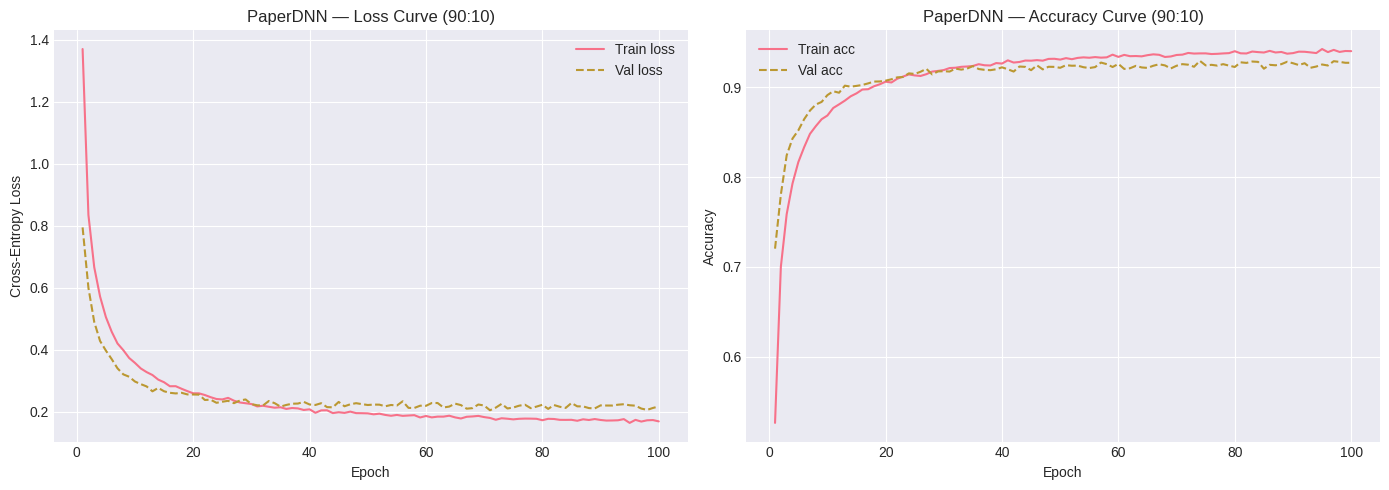

  Curves saved → curves_90_10.png


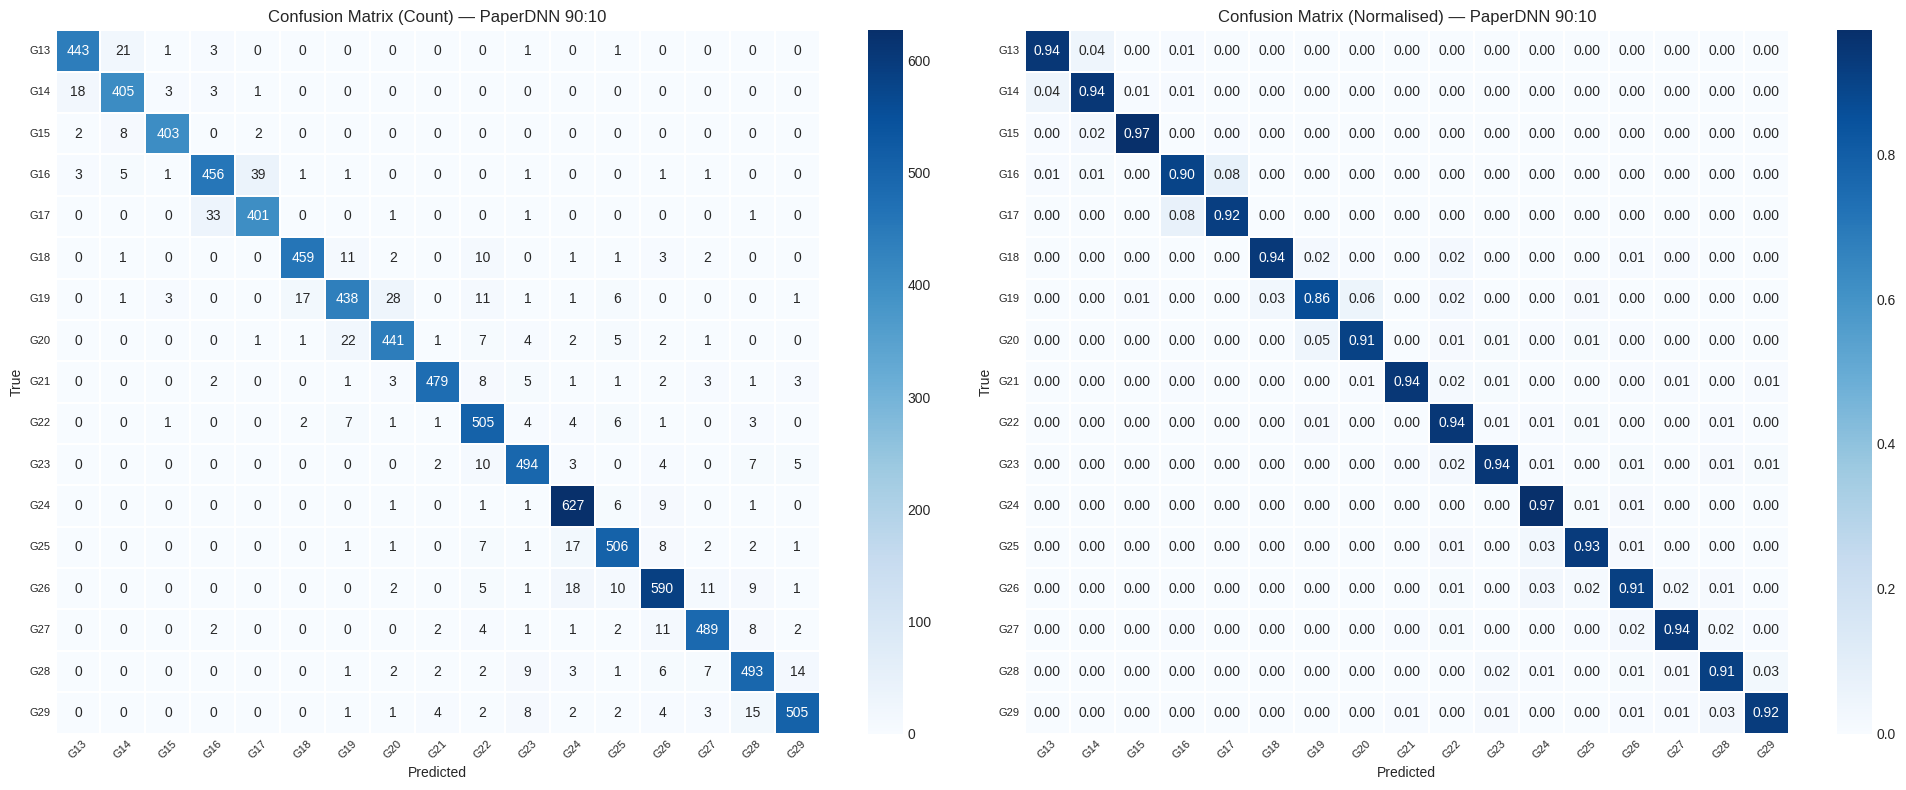

  CM saved → cm_90_10.png


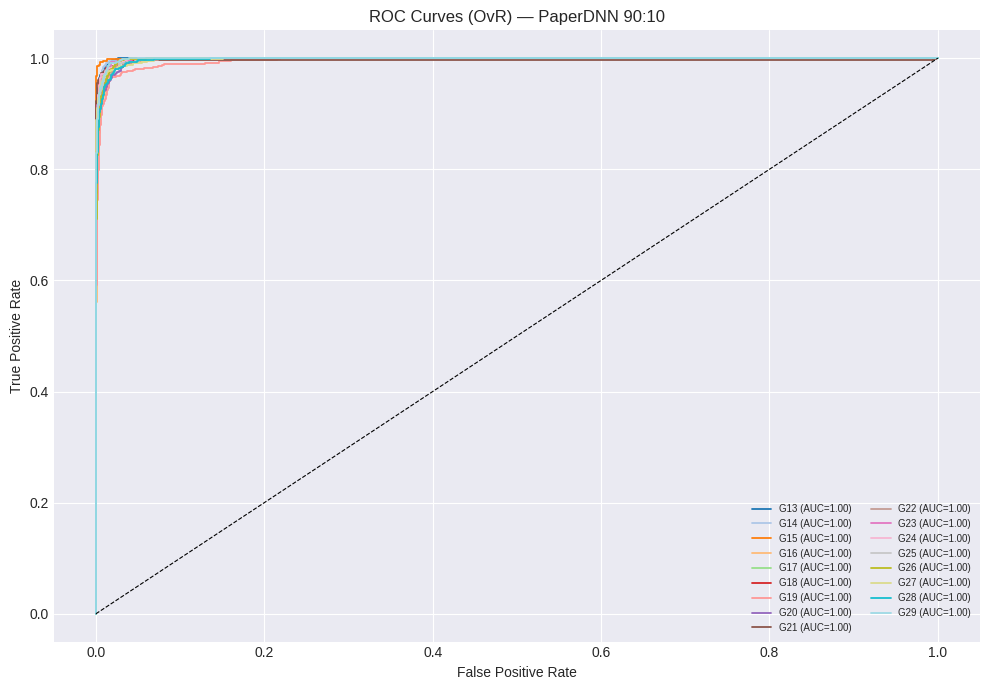

  ROC saved → roc_90_10.png


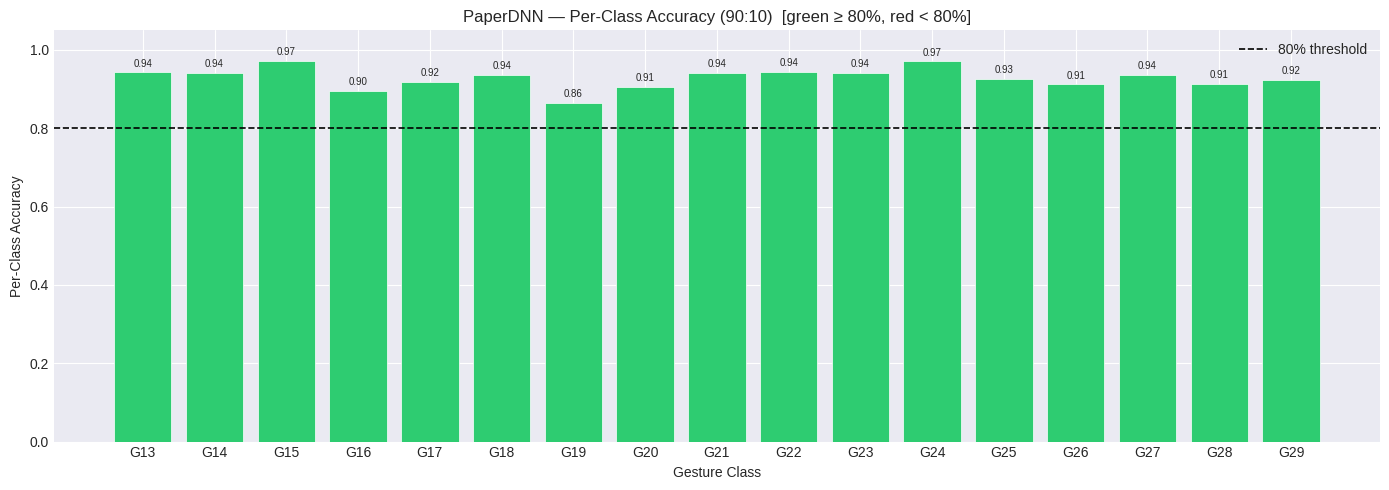

  Per-class chart saved → per_class_acc_90_10.png

  ── Results 90:10 ────────────────────────────────
  Overall Accuracy    : 0.9283
  Balanced Accuracy   : 0.9284  (macro recall — paper metric)
  Precision (weighted): 0.9287
  Recall    (weighted): 0.9283
  F1        (weighted): 0.9283
  Macro Precision     : 0.9294
  Macro Recall        : 0.9284
  Macro F1            : 0.9287
  ROC-AUC (weighted)  : 0.9982
  Train wall          : 185.9 s
  Test wall           : 0.37 s
  Model saved → paperdnn_90_10.pt

  Split 80:20  |  train=80%  test=20%
  Sizes  train=63,081  val=7,010  test=17,523
  Extracting features...


Feature extraction:   0%|          | 0/63081 [00:00<?, ?it/s]

Feature extraction:   0%|          | 0/7010 [00:00<?, ?it/s]

Feature extraction:   0%|          | 0/17523 [00:00<?, ?it/s]

  Feature vector size : 336
  PaperDNN params     : 376,081
  Feature vector size : 336
  Epoch  10  train_loss=0.3612  train_acc=0.8670  val_loss=0.3062  val_acc=0.8853
  Epoch  20  train_loss=0.2602  train_acc=0.9066  val_loss=0.2510  val_acc=0.9114
  Epoch  30  train_loss=0.2168  train_acc=0.9228  val_loss=0.2445  val_acc=0.9146
  Epoch  40  train_loss=0.2008  train_acc=0.9297  val_loss=0.2262  val_acc=0.9194
  Epoch  50  train_loss=0.1910  train_acc=0.9327  val_loss=0.2306  val_acc=0.9211
  Epoch  60  train_loss=0.1746  train_acc=0.9385  val_loss=0.2289  val_acc=0.9224
  Epoch  70  train_loss=0.1720  train_acc=0.9395  val_loss=0.2355  val_acc=0.9230
  Epoch  80  train_loss=0.1683  train_acc=0.9420  val_loss=0.2281  val_acc=0.9274
  Epoch  90  train_loss=0.1697  train_acc=0.9415  val_loss=0.2260  val_acc=0.9244
  Epoch 100  train_loss=0.1637  train_acc=0.9432  val_loss=0.2313  val_acc=0.9225
  Early stop at epoch 100
  Training wall-clock : 157.2 s  |  Best val_loss: 0.2151


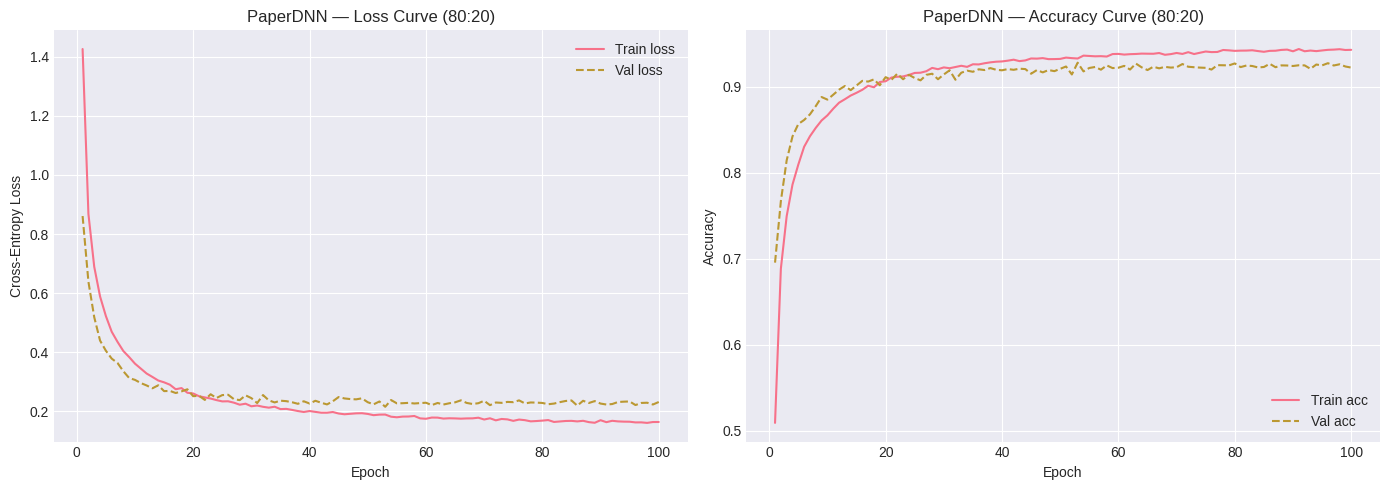

  Curves saved → curves_80_20.png


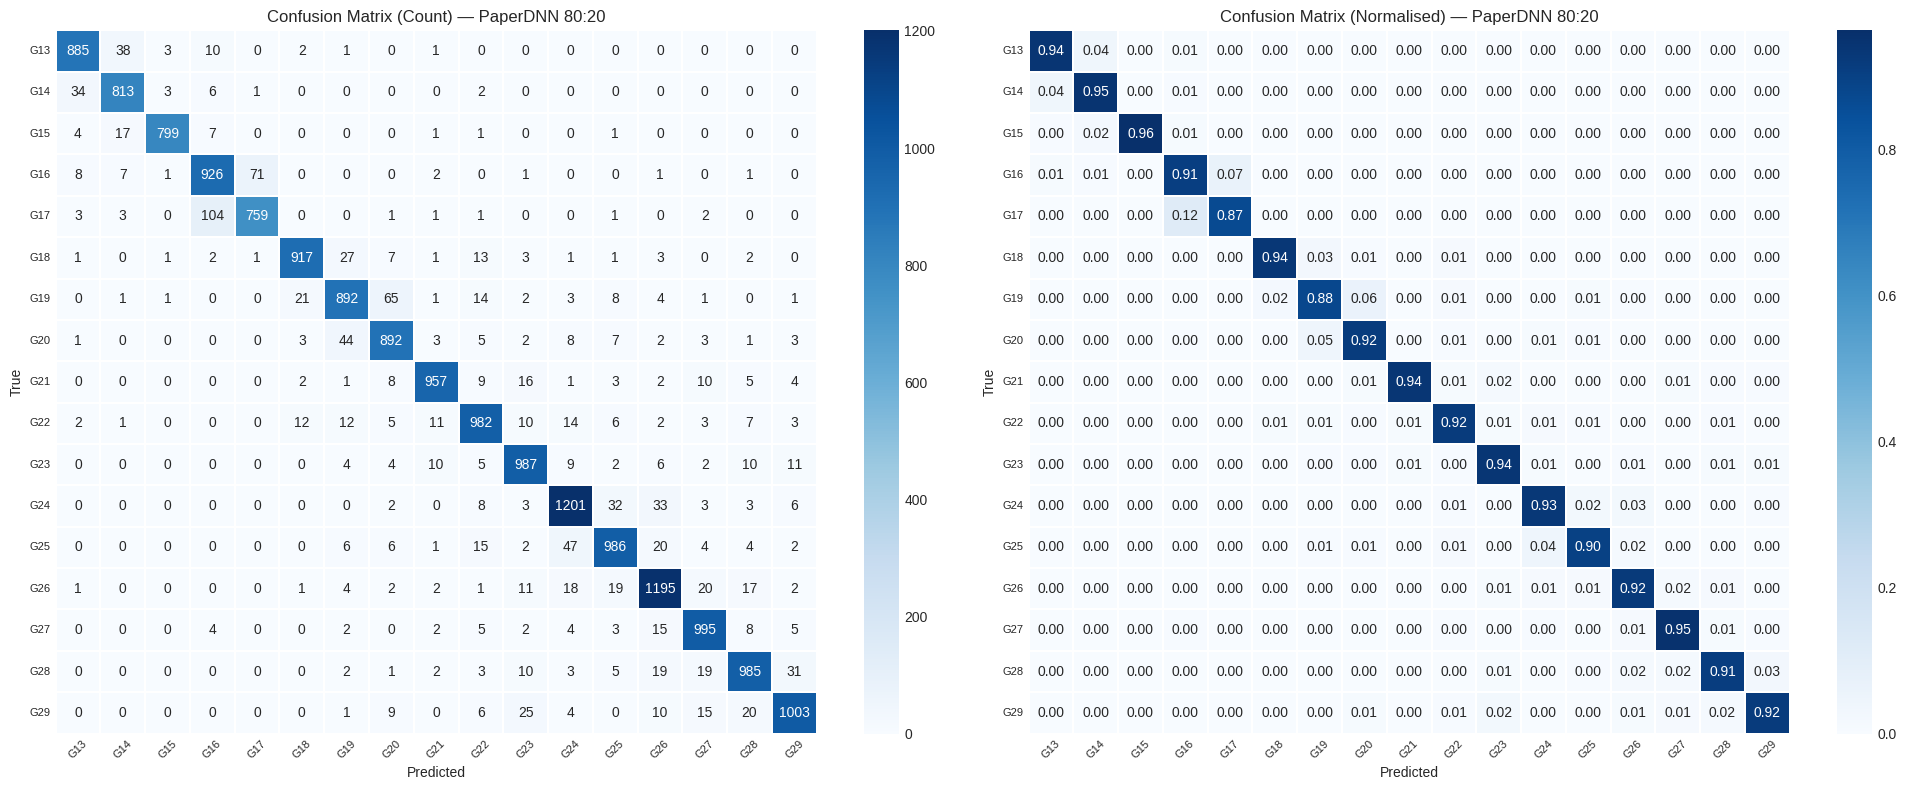

  CM saved → cm_80_20.png


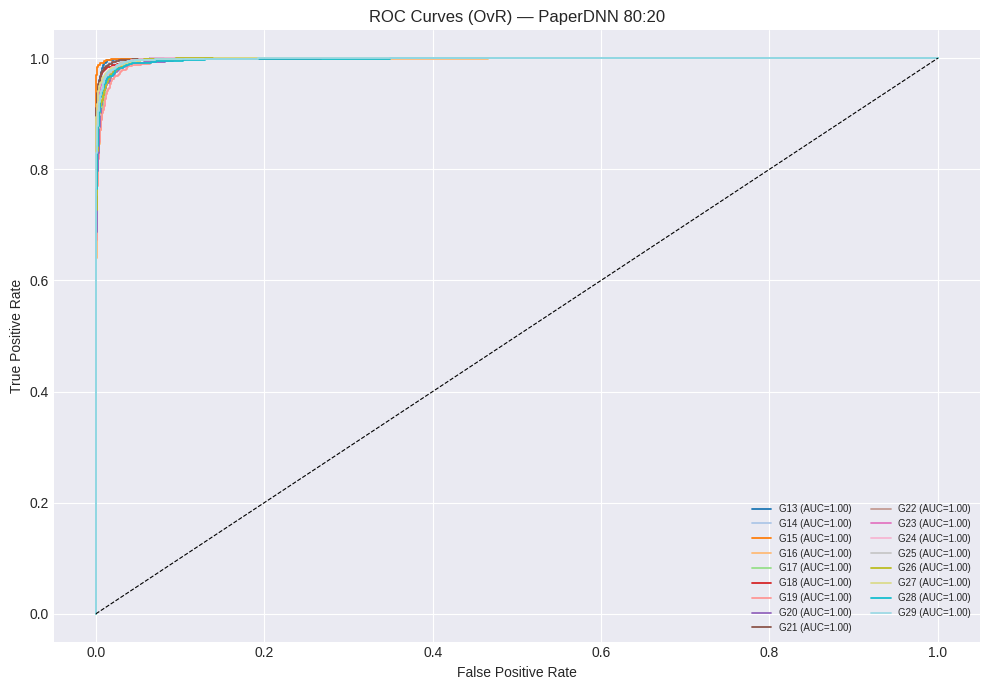

  ROC saved → roc_80_20.png


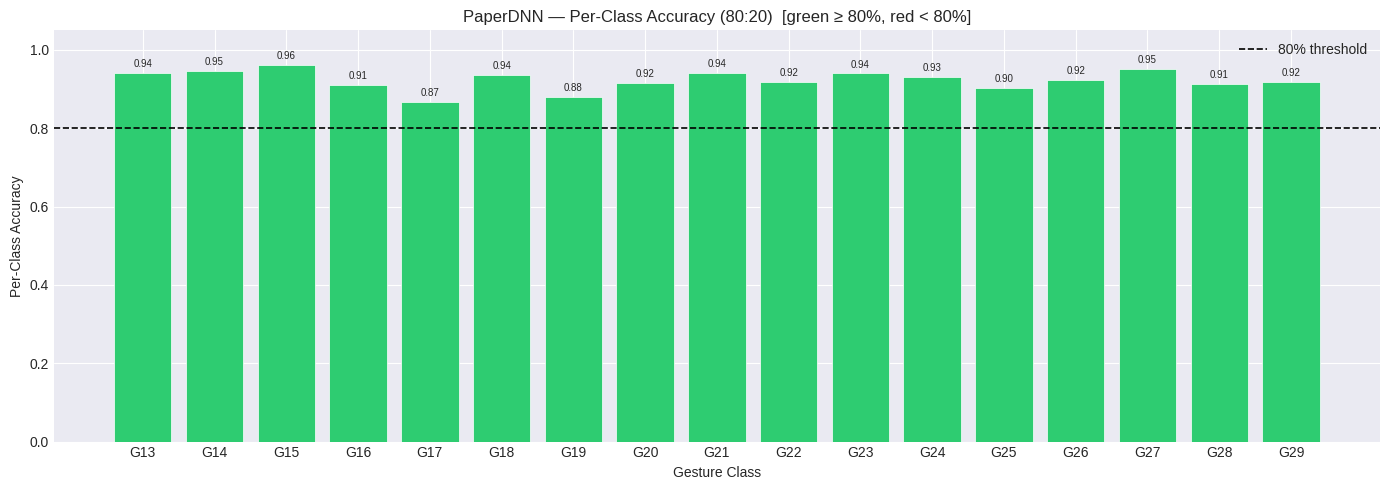

  Per-class chart saved → per_class_acc_80_20.png

  ── Results 80:20 ────────────────────────────────
  Overall Accuracy    : 0.9230
  Balanced Accuracy   : 0.9232  (macro recall — paper metric)
  Precision (weighted): 0.9233
  Recall    (weighted): 0.9230
  F1        (weighted): 0.9230
  Macro Precision     : 0.9244
  Macro Recall        : 0.9232
  Macro F1            : 0.9237
  ROC-AUC (weighted)  : 0.9982
  Train wall          : 157.2 s
  Test wall           : 0.40 s
  Model saved → paperdnn_80_20.pt

  FAILURE MODE ANALYSIS — PaperDNN

  Per-class mean accuracy (worst → best):
         G19  0.872  ██████████████████████████
         G17  0.893  ██████████████████████████
         G16  0.903  ███████████████████████████
         G20  0.911  ███████████████████████████
         G28  0.913  ███████████████████████████
         G25  0.914  ███████████████████████████
         G26  0.918  ███████████████████████████
         G29  0.920  ███████████████████████████
         G22  0.931  

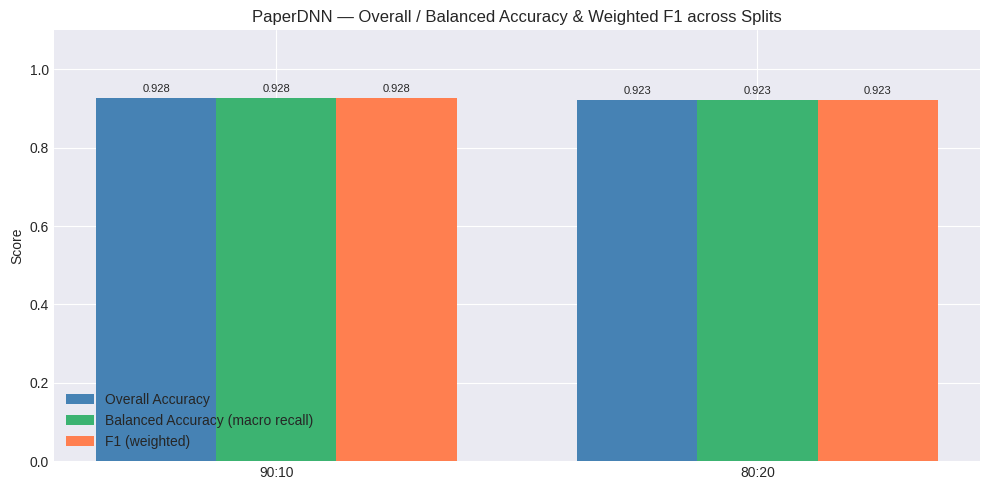


  Summary chart saved → summary_all_splits.png

  FINAL SUMMARY — PaperDNN (Feed-Forward DNN, paper-exact)
split  train_size  test_size  accuracy  balanced_accuracy  precision_w  recall_w     f1_w  precision_mac  recall_mac   f1_mac  roc_auc_w  train_wall_s  test_wall_s
90:10       70966       8762  0.928327           0.928430     0.928685  0.928327 0.928310       0.929366    0.928430 0.928712   0.998169    185.915516     0.373512
80:20       63081      17523  0.923015           0.923243     0.923346  0.923015 0.923047       0.924355    0.923243 0.923658   0.998225    157.242831     0.397950

  Summary CSV  → /kaggle/working/results_dnn_paper/summary_all_splits.csv
  Plots        → /kaggle/working/plots_dnn_paper
  Checkpoints  → /kaggle/working/ckpts_dnn_paper

  Best split: 90:10  (Weighted F1 = 0.9283  |  Balanced Acc = 0.9284)


In [14]:
def main():
    # ── STEP 1: Load subjects ─────────────────────────────────────────────
    print('\n' + '='*70)
    print('  STEP 1 — Loading NinaPro DB7 (Exercise B, gestures 13–29)')
    print('='*70)
    subject_loader = SubjectLoader()
    available_sids, n_acc_ch = subject_loader.process_all(Config.SUBJECTS)
    print(f'\n  Available subjects : {available_sids}')
    print(f'  ACC channels       : {n_acc_ch}')

    # ── STEP 2: Build windows (raw signal) ───────────────────────────────
    print('\n' + '='*70)
    print('  STEP 2 — Building Raw Signal Windows')
    print('='*70)
    X_raw, y, n_channels = subject_loader.build_windows(available_sids, n_acc_ch)
    n_classes   = Config.N_CLASSES
    class_names = [f'G{g}' for g in range(Config.GESTURE_MIN,
                                            Config.GESTURE_MAX + 1)]

    print(f'\n  Total windows  : {len(y):,}')
    print(f'  Input channels : {n_channels} (EMG=12, ACC={n_acc_ch})')
    print(f'  Window size    : {Config.WIN_SAMPLES} samples ({Config.WIN_MS} ms)')
    print(f'  Classes        : {n_classes} → {class_names}')
    uniq, cnts = np.unique(y, return_counts=True)
    for u, c in zip(uniq, cnts):
        print(f'    {class_names[u]:>6s}: {c:>7,} windows ({c/len(y)*100:.1f}%)')

    # ── STEP 3: Train & Evaluate for each split ───────────────────────────
    print('\n' + '='*70)
    print('  STEP 3 — Training & Evaluation (PaperDNN, 2 splits)')
    print('  Model   : Feed-forward DNN  512→256→256  (paper-exact)')
    print('  Input   : Hand-crafted features RMS+MAV+MAVSLP+ZC+SSC+WL')
    print('  Optimizer: Adam lr=0.005, decay=1e-5, NO scheduler')
    print('  Dropout : 20%  |  Init: He Uniform')
    print('='*70)

    experiment  = SplitExperiment(X_raw, y, n_channels, n_classes, class_names)
    all_metrics = []

    for train_frac, test_frac in Config.SPLIT_RATIOS:
        metrics, y_true, y_proba = experiment.run(train_frac, test_frac)
        all_metrics.append(metrics)
        tag   = metrics['split'].replace(':', '_')
        jpath = Config.RESULTS_DIR / f'metrics_{tag}.json'
        m_save = {k: v for k, v in metrics.items() if k != 'per_class_acc'}
        m_save['per_class_acc'] = metrics['per_class_acc']
        with open(jpath, 'w') as f:
            json.dump(m_save, f, indent=2)
        gc.collect()

    # ── STEP 4: Failure mode analysis ────────────────────────────────────
    best_split = analyse_failure_modes(all_metrics, class_names)

    # ── STEP 5: Summary CSV ───────────────────────────────────────────────
    rows = [{k: v for k, v in m.items() if k != 'per_class_acc'}
            for m in all_metrics]
    df       = pd.DataFrame(rows)
    csv_path = Config.RESULTS_DIR / 'summary_all_splits.csv'
    df.to_csv(csv_path, index=False)

    print(f'\n{"="*70}')
    print('  FINAL SUMMARY — PaperDNN (Feed-Forward DNN, paper-exact)')
    print(f'{"="*70}')
    print(df[['split', 'train_size', 'test_size',
              'accuracy', 'balanced_accuracy',
              'precision_w', 'recall_w', 'f1_w',
              'precision_mac', 'recall_mac', 'f1_mac',
              'roc_auc_w', 'train_wall_s', 'test_wall_s']].to_string(index=False))
    print(f'\n  Summary CSV  → {csv_path}')
    print(f'  Plots        → {Config.PLOT_DIR}')
    print(f'  Checkpoints  → {Config.CKPT_DIR}')
    print(f'\n  Best split: {best_split["split"]}'
          f'  (Weighted F1 = {best_split["f1_w"]:.4f}'
          f'  |  Balanced Acc = {best_split["balanced_accuracy"]:.4f})')


if __name__ == '__main__':
    main()